In [ ]:
!pip install networkx pandas numpy torch opencv-python matplotlib seaborn scikit-learn plotly rpy2 cdlib libpysal spreg captum pysnooper fire
!pip install torch_geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.6/263.6 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.4 MB/s eta 0:00:00


In [ ]:
import pickle
import torch
import cv2
import numpy as np
import networkx as nx
from torch_geometric.utils.convert import to_networkx, from_networkx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import copy
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.base import BaseEstimator, ClassifierMixin
import torch.nn.functional as F
from torch import nn
from torch.nn import Linear
from torch_geometric.data import DataLoader, Data, InMemoryDataset
from torch.utils.data import TensorDataset
from torch_geometric.nn import GCNConv
from functools import reduce
import tqdm


from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from google.colab.patches import cv2_imshow
from sklearn.neighbors import NearestNeighbors
from torch_geometric.transforms import RandomNodeSplit

In [ ]:
file_name = 'lymphocyte_toy_data.pkl'

with open(file_name, 'rb') as file:
  data = pickle.load(file)
print(f"Data loaded successfully. Data type: {type(data)}")

print(data.keys())
print(data['X'][31]['y'])

Data loaded successfully. Data type: <class 'dict'>
dict_keys(['ims', 'X', 'y', 'X_graph', 'y_graph'])
tensor([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0])


In [ ]:
images_list = data['ims']
preprocessed_images = []
target_size = (224, 224)
originalWidth = data['ims'][0].shape[1]
originalHeight = data['ims'][0].shape[0]

#for img in images_list:
  #resizedImg = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
  #resized_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2GRAY)
  #resized_img = cv2.normalize(resized_img, None, 0, 1, cv2.NORM_MINMAX, dtype=cv2.CV_32F)
  #resized_img = cv2.GaussianBlur(resized_img, (3, 3), 0)
  #preprocessed_images.append(resizedImg)

#data['ims'] = preprocessed_images
#cv2_imshow(data['ims'][31])

In [ ]:
def buildGraphForImage(data, idx, originalWidth, originalHeight, target_size=224):
  G = nx.Graph()
  posDict = {}
  for i,j in data["X"][idx].edge_index.T:
    if i != j:
      i = int(i)
      j = int(j)
      G.add_edge(i, j)

  for node in G.nodes():
    x = data["X"][idx]["pos"][node, 0].item()
    y = data["X"][idx]["pos"][node, 1].item()

    posDict[node] = (x, y)


  return G, posDict

In [ ]:
graphs = {}
positions = {}

for idx in range(len(data["ims"])):
    G, posDict = buildGraphForImage(
        data=data,
        idx=idx,
        originalWidth=originalWidth,
        originalHeight=originalHeight
    )

    graphs[idx] = G
    positions[idx] = posDict

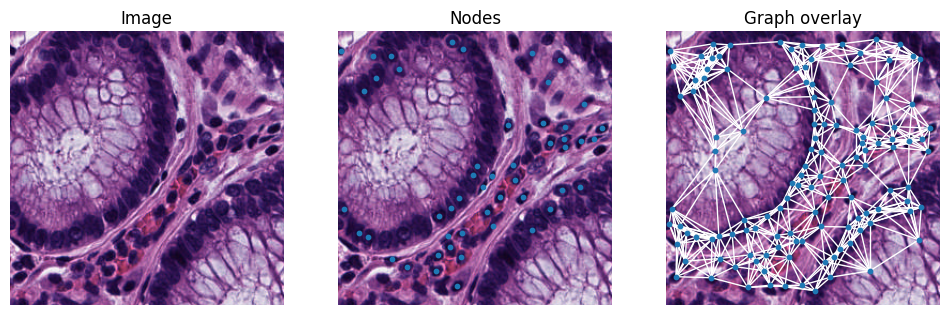

In [ ]:
idx_img = 31

plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(data["ims"][idx_img])
plt.axis("off")
plt.title("Image")

plt.subplot(132)
nx.draw(graphs[idx],pos=positions[idx_img],node_size=10,edge_color="none",width=1.0,with_labels=False)
plt.imshow(data["ims"][idx_img])
plt.axis("off")
plt.title("Nodes")

plt.subplot(133)
nx.draw(graphs[idx_img], pos=positions[idx_img],node_size=10,edge_color="white",width=1.0,with_labels=False)
plt.imshow(data["ims"][idx_img])
plt.axis("off")
plt.title("Graph overlay")

plt.show()

In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from umap import UMAP

def processImage(data, idx, patchSize=32):
  dataIdx = data['X'][idx]
  img = data['ims'][idx]

  xFeats = dataIdx["x"].numpy()
  positions = dataIdx["pos"].numpy().astype(int)
  labels = dataIdx["y"].numpy()

  umapCoords = UMAP(n_components=2, random_state=42).fit_transform(xFeats)

  height, width = img.shape[:2]

  heImages = []
  validCoords = []
  validLabels = []
  validNodeIndices = []
  #patch extraction
  for nodeIdx, ((x, y), coord, label) in enumerate(zip(positions, umapCoords, labels)):
      x1, x2 = x - patchSize, x + patchSize
      y1, y2 = y - patchSize, y + patchSize

      if x1 >= 0 and y1 >= 0 and x2 < width and y2 < height:
          patch = img[y1:y2, x1:x2]
          heImages.append(patch)
          validCoords.append(coord)
          validLabels.append(label)
          validNodeIndices.append(nodeIdx)

  fig, ax = plt.subplots(figsize=(10, 10))
  ax.scatter([coords[0] for coords in validCoords], [coords[1] for coords in validCoords], s=5, alpha=0.0, label="Cells")

  for (x, y), patch in zip(validCoords, heImages):
    try:
      imagebox = OffsetImage(patch, zoom=1.6)
      ab = AnnotationBbox(imagebox, (x, y), frameon=False)
      ax.add_artist(ab)
    except:
      pass

  # ax.set_title("Cell Patch Overlay on UMAP (Lymphocyte Graph)")
  ax.axis("off")
  plt.title(f"Image {idx}")
  plt.show()

  return heImages, validCoords, validLabels, validNodeIndices

In [ ]:
all_patches = {}

for idx in range(len(data["ims"])):
    print(f"Processing image {idx}...")

    patches, coords, labels, nodeIndices = processImage(data, idx)

    all_patches[idx] = {"patches": patches,"coords": coords,"labels": labels, "nodeIndices": nodeIndices}

In [ ]:
cnnModel = VGG16(weights='imagenet', include_top=False, pooling='avg')

def extractVGGFeaturesBatched(patches, cnnModel, batchSize=64):
  allFeatures = []

  for start in range(0, len(patches), batchSize):
    batchPatches = patches[start:start + batchSize]
    resizedImages = np.array([cv2.resize(img, target_size, interpolation=cv2.INTER_CUBIC) for img in batchPatches])

    # 2. Preprocess (N, 224, 224, 3) numpy array
    x = preprocess_input(resizedImages.astype('float32'))

    # 3. Extract feature vectors
    batchFeatures = cnnModel.predict(x, verbose = 0) # Output shape: (N, 512)
    print(batchFeatures.shape)

    allFeatures.append(batchFeatures)

  features = np.vstack(allFeatures)

  return features

In [ ]:
patches = all_patches[28]["patches"]

features = extractVGGFeaturesBatched(patches,cnnModel,batchSize=64)
print(features.shape)

(56, 512)
(56, 512)


In [ ]:
allVGGFeatures = {}

for idx in range(len(data["ims"])):
    print(f"Processing image {idx}...")

    patches = all_patches[idx]["patches"]
    coords  = all_patches[idx]["coords"]
    labels  = all_patches[idx]["labels"]

    features = extractVGGFeaturesBatched(patches,cnnModel,batchSize=64)

    allVGGFeatures[idx] = {"features": features,"coords": coords,"labels": labels}

    print(f"Image {idx}: {features.shape}")

Processing image 0...
(36, 512)
Image 0: (36, 512)
Processing image 1...
(48, 512)
Image 1: (48, 512)
Processing image 2...
(44, 512)
Image 2: (44, 512)
Processing image 3...
(50, 512)
Image 3: (50, 512)
Processing image 4...
(59, 512)
Image 4: (59, 512)
Processing image 5...
(42, 512)
Image 5: (42, 512)
Processing image 6...
(64, 512)
(24, 512)
Image 6: (88, 512)
Processing image 7...
(37, 512)
Image 7: (37, 512)
Processing image 8...
(64, 512)
(16, 512)
Image 8: (80, 512)
Processing image 9...
(64, 512)
(10, 512)
Image 9: (74, 512)
Processing image 10...
(43, 512)
Image 10: (43, 512)
Processing image 11...
(45, 512)
Image 11: (45, 512)
Processing image 12...
(37, 512)
Image 12: (37, 512)
Processing image 13...
(64, 512)
(37, 512)
Image 13: (101, 512)
Processing image 14...
(28, 512)
Image 14: (28, 512)
Processing image 15...
(64, 512)
(12, 512)
Image 15: (76, 512)
Processing image 16...
(42, 512)
Image 16: (42, 512)
Processing image 17...
(55, 512)
Image 17: (55, 512)
Processing imag

In [ ]:
for idx in range(len(data["ims"])):
    G = graphs[idx]

    features = allVGGFeatures[idx]["features"]
    labels = allVGGFeatures[idx]["labels"]
    nodeIndices = all_patches[idx]["nodeIndices"]

    for k, nodeIdx in enumerate(nodeIndices):
        nodeIdx = int(nodeIdx)

        if nodeIdx in G.nodes:
            G.nodes[nodeIdx]["x"] = features[k]
            G.nodes[nodeIdx]["y"] = int(labels[k])

In [ ]:
idx_nodecheck = 0
G = graphs[idx_nodecheck]

print("Total nodes:", G.number_of_nodes())
print("Nodes with x:", sum("x" in G.nodes[n] for n in G.nodes()))
print("Nodes with y:", sum("y" in G.nodes[n] for n in G.nodes()))
print("Nodes with both:", sum(("x" in G.nodes[n]) and ("y" in G.nodes[n]) for n in G.nodes()))

Total nodes: 63
Nodes with x: 36
Nodes with y: 36
Nodes with both: 36


In [ ]:
def nxToPyg(G):
    # keep only nodes that have features
    valid_nodes = [n for n in G.nodes() if "x" in G.nodes[n]]

    node_to_idx = {node: i for i, node in enumerate(valid_nodes)}

    # node features
    x = torch.tensor(
        [G.nodes[node]["x"] for node in valid_nodes],
        dtype=torch.float
    )

    y = torch.tensor(
        [G.nodes[node]["y"] for node in valid_nodes],
        dtype=torch.long
    )

    # edges
    edge_index = []

    for src, dst in G.edges():
      if src in node_to_idx and dst in node_to_idx:
        edge_index.append([node_to_idx[src], node_to_idx[dst]])
        edge_index.append([node_to_idx[dst], node_to_idx[src]])

    edge_index = torch.tensor(edge_index, dtype=torch.long).T

    data = Data(
        x=x,
        edge_index=edge_index,
        y=y
    )

    return data

In [ ]:
pyg_graphs = []

for idx in graphs:
    pyg_data = nxToPyg(graphs[idx])
    pyg_data.image_idx = idx
    pyg_graphs.append(pyg_data)

print(pyg_graphs[0])
print(pyg_graphs[0].x.shape)
print(pyg_graphs[0].edge_index.shape)
print(pyg_graphs[0].y.shape)

Data(x=[36, 512], edge_index=[2, 282], y=[36], image_idx=0)
torch.Size([36, 512])
torch.Size([2, 282])
torch.Size([36])


In [ ]:
import random

random.seed(42)

random.shuffle(pyg_graphs)

train_graphs = pyg_graphs[:50]
test_graphs  = pyg_graphs[50:]
train_loader = DataLoader(train_graphs, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_graphs, batch_size=8)

In [ ]:
class GCN(nn.Module):
    def __init__(self, inputDim, hiddenDim, outputDim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(inputDim, hiddenDim)
        self.ln1 = nn.LayerNorm(hiddenDim)
        self.conv2 = GCNConv(hiddenDim, outputDim)

    def forward(self, featureData, edgeInfo):
        x = self.conv1(featureData, edgeInfo)
        x = self.ln1(x)
        x = F.relu(x)
        x = F.dropout(x, p = 0.5, training = self.training)
        #Second GCN layer
        x = self.conv2(x, edgeInfo)
        return F.log_softmax(x, dim = 1)

# Initialize the model
num_features=512
num_classes=2
GCNmodel = GCN(num_features, 128, num_classes)

optimizer = torch.optim.Adam(GCNmodel.parameters(), lr = 0.001, weight_decay = 5e-4)

In [ ]:
#criterion = torch.nn.MSELoss()

def trainModel():
    GCNmodel.train()
    total_loss = 0

    for batch in train_loader:
      optimizer.zero_grad()
      output = GCNmodel(batch.x, batch.edge_index)
      loss = F.nll_loss(output, batch.y)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()
    return total_loss / len(train_loader)

for epoch in range(200):
  lossValue = trainModel()
  print(f'Epoch: {epoch+1:03d}, Loss: {lossValue:.4f}')

Epoch: 001, Loss: 0.7397
Epoch: 002, Loss: 0.6665
Epoch: 003, Loss: 0.6293
Epoch: 004, Loss: 0.6105
Epoch: 005, Loss: 0.5997
Epoch: 006, Loss: 0.6010
Epoch: 007, Loss: 0.5799
Epoch: 008, Loss: 0.5939
Epoch: 009, Loss: 0.5909
Epoch: 010, Loss: 0.5810
Epoch: 011, Loss: 0.5721
Epoch: 012, Loss: 0.5665
Epoch: 013, Loss: 0.5252
Epoch: 014, Loss: 0.5540
Epoch: 015, Loss: 0.5264
Epoch: 016, Loss: 0.5008
Epoch: 017, Loss: 0.5407
Epoch: 018, Loss: 0.5371
Epoch: 019, Loss: 0.5392
Epoch: 020, Loss: 0.5047
Epoch: 021, Loss: 0.5015
Epoch: 022, Loss: 0.5196
Epoch: 023, Loss: 0.4825
Epoch: 024, Loss: 0.4668
Epoch: 025, Loss: 0.4718
Epoch: 026, Loss: 0.4722
Epoch: 027, Loss: 0.4638
Epoch: 028, Loss: 0.4546
Epoch: 029, Loss: 0.4655
Epoch: 030, Loss: 0.4516
Epoch: 031, Loss: 0.4645
Epoch: 032, Loss: 0.4853
Epoch: 033, Loss: 0.4532
Epoch: 034, Loss: 0.4635
Epoch: 035, Loss: 0.4476
Epoch: 036, Loss: 0.4405
Epoch: 037, Loss: 0.4312
Epoch: 038, Loss: 0.4332
Epoch: 039, Loss: 0.4053
Epoch: 040, Loss: 0.4099


In [ ]:
def evaluateModel(test_loader):
  GCNmodel.eval()
  correct = 0
  eval = 0
  total = 0
  with torch.no_grad():
    for batch in test_loader:
      predictions = GCNmodel(batch.x, batch.edge_index).argmax(dim=1)
      # Calculate how far off the predictions are on average
      correct += (predictions == batch.y).sum().item()
      total += batch.y.size(0)
      #error = torch.abs(predictions[pyg_graph.test_mask] - pyg_graph.y[pyg_graph.test_mask]).mean()
  acc = correct/total
  return acc
accuracy = evaluateModel(test_loader)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.5542


In [ ]:
def get_auc_score(loader):
    GCNmodel.eval()
    allScores = []
    allLabels = []
    with torch.no_grad():
      for batch in loader:
        out = GCNmodel(batch.x, batch.edge_index)

        probs = torch.exp(out)[:, 1]

        allScores.append(probs.cpu())
        allLabels.append(batch.y.cpu())

    yScores = torch.cat(allScores).numpy()
    yTrue = torch.cat(allLabels).numpy()

    # Calculate AUC
    return roc_auc_score(yTrue, yScores)

auc = get_auc_score(test_loader)
print(f'Test AUC: {auc:.4f}')

Test AUC: 0.5897


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
def includePrecisionRecallF1(loader):
    GCNmodel.eval()

    allPreds = []
    allLabels = []

    with torch.no_grad():
        for batch in loader:
            out = GCNmodel(batch.x, batch.edge_index)
            preds = out.argmax(dim=1)

            allPreds.append(preds.cpu())
            allLabels.append(batch.y.cpu())

    yPred = torch.cat(allPreds).numpy()
    yTrue = torch.cat(allLabels).numpy()

    precision = precision_score(yTrue, yPred, average="binary")
    recall = recall_score(yTrue, yPred, average="binary")
    f1 = f1_score(yTrue, yPred, average="binary")

    return precision, recall, f1

precision, recall, f1 = includePrecisionRecallF1(test_loader)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Precision: 0.4857
Recall:    0.4833
F1 Score:  0.4845


In [ ]:
def make_feature_dataset(pyg_graphs):
    X_list = []
    y_list = []

    for graph in pyg_graphs:
        X_list.append(graph.x)
        y_list.append(graph.y)

    X = torch.cat(X_list, dim=0)
    y = torch.cat(y_list, dim=0)

    return X, y

In [ ]:
X_train, y_train = make_feature_dataset(train_graphs)
X_test, y_test   = make_feature_dataset(test_graphs)

train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)

train_loader_img = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader_img  = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [ ]:
class VGGFeatureMLP(nn.Module):
    def __init__(self, inputDim=512, hiddenDim=128, outputDim=2):
        super().__init__()

        self.fc1 = nn.Linear(inputDim, hiddenDim)
        self.fc2 = nn.Linear(hiddenDim, outputDim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.fc2(x)

        return F.log_softmax(x, dim=1)

In [ ]:
mlp_model = VGGFeatureMLP(
    inputDim=512,
    hiddenDim=128,
    outputDim=2
)

mlp_optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)

In [ ]:
def train_mlp():
    mlp_model.train()
    total_loss = 0

    for x_batch, y_batch in train_loader_img:
        mlp_optimizer.zero_grad()

        out = mlp_model(x_batch)
        loss = F.nll_loss(out, y_batch)

        loss.backward()
        mlp_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader_img)

for epoch in range(200):
    loss = train_mlp()
    print(f"Epoch {epoch+1:03d}, Loss: {loss:.4f}")

Epoch 001, Loss: 0.7352
Epoch 002, Loss: 0.6025
Epoch 003, Loss: 0.5820
Epoch 004, Loss: 0.5624
Epoch 005, Loss: 0.5417
Epoch 006, Loss: 0.5246
Epoch 007, Loss: 0.5102
Epoch 008, Loss: 0.4876
Epoch 009, Loss: 0.4805
Epoch 010, Loss: 0.4686
Epoch 011, Loss: 0.4523
Epoch 012, Loss: 0.4358
Epoch 013, Loss: 0.4233
Epoch 014, Loss: 0.4184
Epoch 015, Loss: 0.4105
Epoch 016, Loss: 0.4011
Epoch 017, Loss: 0.3839
Epoch 018, Loss: 0.3812
Epoch 019, Loss: 0.3697
Epoch 020, Loss: 0.3649
Epoch 021, Loss: 0.3557
Epoch 022, Loss: 0.3390
Epoch 023, Loss: 0.3349
Epoch 024, Loss: 0.3110
Epoch 025, Loss: 0.3241
Epoch 026, Loss: 0.3135
Epoch 027, Loss: 0.3214
Epoch 028, Loss: 0.2995
Epoch 029, Loss: 0.2811
Epoch 030, Loss: 0.2706
Epoch 031, Loss: 0.2742
Epoch 032, Loss: 0.2749
Epoch 033, Loss: 0.2488
Epoch 034, Loss: 0.2494
Epoch 035, Loss: 0.2460
Epoch 036, Loss: 0.2362
Epoch 037, Loss: 0.2399
Epoch 038, Loss: 0.2302
Epoch 039, Loss: 0.2123
Epoch 040, Loss: 0.2125
Epoch 041, Loss: 0.2061
Epoch 042, Loss:

In [ ]:
def evaluate_mlp(loader):
    mlp_model.eval()

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            out = mlp_model(x_batch)

            probs = torch.exp(out)[:, 1]
            preds = out.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_probs.append(probs.cpu())
            all_labels.append(y_batch.cpu())

    y_pred = torch.cat(all_preds).numpy()
    y_prob = torch.cat(all_probs).numpy()
    y_true = torch.cat(all_labels).numpy()

    acc = (y_pred == y_true).mean()
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    return acc, precision, recall, f1, auc

In [ ]:
acc_mlp, precision_mlp, recall_mlp, f1_mlp, auc_mlp = evaluate_mlp(test_loader_img)

print(f"Image-only Accuracy:  {acc_mlp:.4f}")
print(f"Image-only Precision: {precision_mlp:.4f}")
print(f"Image-only Recall:    {recall_mlp:.4f}")
print(f"Image-only F1:        {f1_mlp:.4f}")
print(f"Image-only AUC:       {auc_mlp:.4f}")

Image-only Accuracy:  0.6257
Image-only Precision: 0.5589
Image-only Recall:    0.5210
Image-only F1:        0.5393
Image-only AUC:       0.6351


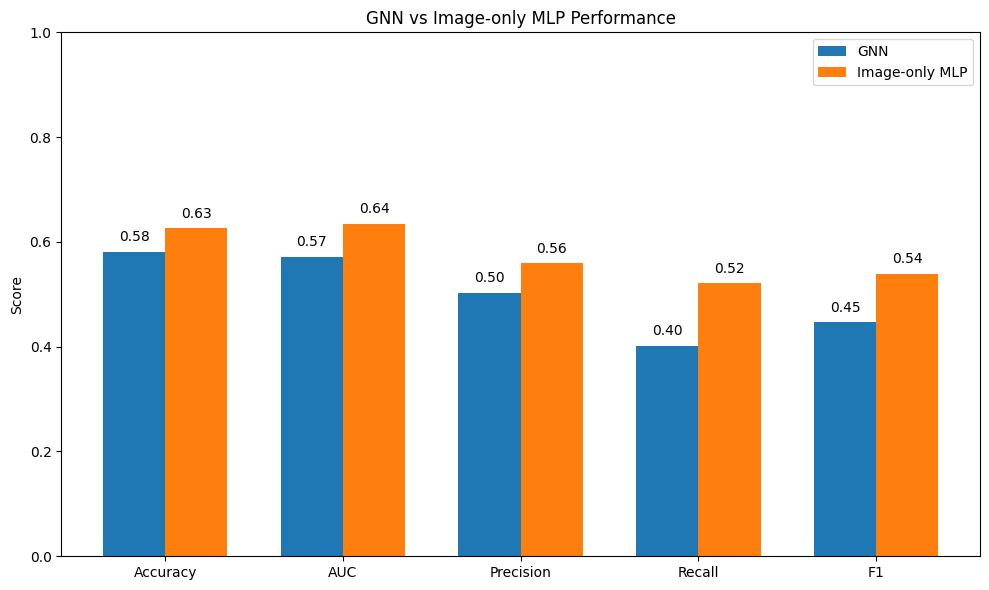

In [ ]:
metrics = ["Accuracy", "AUC", "Precision", "Recall", "F1"]

gnn_scores = [accuracy, auc, precision, recall, f1]
mlp_scores = [acc_mlp, auc_mlp, precision_mlp, recall_mlp, f1_mlp]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, gnn_scores, width, label="GNN")
plt.bar(x + width/2, mlp_scores, width, label="Image-only MLP")

plt.xticks(x, metrics)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("GNN vs Image-only MLP Performance")
plt.legend()

for i, score in enumerate(gnn_scores):
    plt.text(i - width/2, score + 0.02, f"{score:.2f}", ha="center")

for i, score in enumerate(mlp_scores):
    plt.text(i + width/2, score + 0.02, f"{score:.2f}", ha="center")

plt.tight_layout()
plt.show()